<a href="https://colab.research.google.com/github/Aarsha203/Aarsha203/blob/main/Biocogniz_Primer_Designer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧬 Primer Design & In Silico Analysis
## Biocogniz Workshop Notebook
**Instructor:** Aarsha | Reseach Scientist, Biocogniz  
**Contact:** aarshabiocogniz@gmail.com  
**Duration:** 40 min demo + 20 min hands-on

---

### 📋 What This Notebook Does
1. **Installs** required bioinformatics libraries
2. **Loads** a gene sequence (Human Beta-Actin, NM_001101.5)
3. **Designs** optimal primer pairs using Primer3
4. **Analyzes** Tm, GC%, self-dimers, and hairpins
5. **Visualizes** results with matplotlib charts
6. **Interactive widget** for your own custom sequence
7. **Exports** results to CSV

### 🔬 References
- Primer3: Untergasser et al. (2012) NAR. DOI: 10.1093/nar/gks596
- SantaLucia (1998) PNAS 95:1460-1465 — Thermodynamic parameters
- NCBI Primer-BLAST: Ye et al. (2012) BMC Bioinformatics. PMID: 22708584

---
> **💡 Tip:** Run all cells with `Runtime → Run all` (Ctrl+F9)

## 📦 Cell 1: Install Libraries
This installs all required packages. Takes ~60 seconds on first run.

In [ ]:
# ============================================================
# CELL 1: Installation
# Biocogniz Workshop — Primer Design & In Silico Analysis
# ============================================================

import subprocess, sys

print('⏳ Installing packages... (this takes ~60 sec on first run)')
subprocess.run([
    sys.executable, '-m', 'pip', 'install',
    'biopython', 'primer3-py', 'pandas', 'matplotlib',
    'ipywidgets', 'seaborn', '--quiet'
], check=True)
print('✅ All packages installed successfully!')

# Core imports
import primer3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
BIOCOGNIZ_BLUE   = '#19376D'
BIOCOGNIZ_TEAL   = '#0D9488'
BIOCOGNIZ_GREEN  = '#047857'
BIOCOGNIZ_LIGHT  = '#E0F7FA'

print('\n📚 Library versions:')
print(f'   primer3-py : {primer3.__version__}')
print(f'   pandas     : {pd.__version__}')
print(f'\n🚀 Ready for primer design!')

⏳ Installing packages... (this takes ~60 sec on first run)
✅ All packages installed successfully!

📚 Library versions:
   primer3-py : 2.3.0
   pandas     : 2.2.2

🚀 Ready for primer design!


---
## 🧬 Cell 2: Load Gene Sequence
We use **Human Beta-Actin (ACTB)** — a classic housekeeping gene, widely used as a PCR control.

**Source:** NCBI RefSeq NM_001101.5  
**Reference:** Eisenberg & Levanon (2003) Trends Genet. PMID: 14550631

In [ ]:
# ============================================================
# CELL 2: Load Gene Sequence
# Human Beta-Actin CDS — NCBI NM_001101.5
# ============================================================

# Beta-Actin (ACTB) — partial CDS, uppercase DNA sequence
gene_id = 'ACTB'
gene_name = 'Human Beta-Actin (ACTB)'
ncbi_id = 'NM_001101.5'

gene_sequence = (
    'ATGGATGATGATATCGCCGCGCTCGTCGTCGACAACGGCTCCGGCATGTGCAAAGCC'
    'GGCTTCGCGGGCGACGATGCCCCGAGGGCCGTGCCCAGGGAGACCAAACTGGAGTTC'
    'ATCACCAACAAAGAGGGCTATGCCCTCCCACACGCCATCCTGCGTCTGGACCTGGCT'
    'GGCCGGGACCTGACTGACTACCTCATGAAGATCCTCACCGAGCGCGGCTACAGCTTC'
    'ACCACCACGGCCGAGCGGGAAATTGTGCGTGACATTAAGGAGAAGCTGTGCTACGTC'
    'GCCCTGGACTTCGAGCAAGAGATGGCCACGGCTGCTTCCAGCTCCTCCCTGGAGAAG'
    'AGCTACGAGCTGCCTGACGGCCAGGTCATCACCATTGGCAATGAGCGGTTCCGCTGC'
    'CCTGAGGCACTCTTCCAGCCTTCCTTCCTGGGCATGGAGTCCTGTGGCATCCACGAA'
    'ACTACCTTCAACTCCATCATGAAGTGTGACGTGGACATCCGCAAAGACCTGTACGCC'
)

# Calculate basic statistics
seq_len = len(gene_sequence)
gc_content = (gene_sequence.count('G') + gene_sequence.count('C')) / seq_len * 100

print('=' * 55)
print(f'  Gene          : {gene_name}')
print(f'  NCBI Accession: {ncbi_id}')
print(f'  Sequence length: {seq_len} bp')
print(f'  GC Content     : {gc_content:.1f}%')
print('=' * 55)
print(f'\nSequence preview (first 60 bp):')
print(f'  5\'-{gene_sequence[:60]}-3\'')
print(f'\n✅ Sequence loaded and ready for primer design!')

  Gene          : Human Beta-Actin (ACTB)
  NCBI Accession: NM_001101.5
  Sequence length: 513 bp
  GC Content     : 60.2%

Sequence preview (first 60 bp):
  5'-ATGGATGATGATATCGCCGCGCTCGTCGTCGACAACGGCTCCGGCATGTGCAAAGCCGGC-3'

✅ Sequence loaded and ready for primer design!


---
## ⚙️ Cell 3: Design Primers with primer3-py

**Primer3** uses thermodynamic nearest-neighbor models (SantaLucia 1998) to calculate Tm and penalize bad primers.  
We set constraints following standard PCR primer design guidelines:

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Optimal Tm | 60°C | Typical PCR annealing |
| Tm range | 57–63°C | ±3°C flexibility |
| GC% range | 40–60% | Stability without bias |
| Length | 18–25 bp | Specificity vs. accessibility |
| Amplicon | 100–300 bp | Efficient standard PCR |

In [ ]:
# ============================================================
# CELL 3: Design Primers using primer3-py
# Reference: Rozen & Skaletsky (2000) DOI: 10.1007/978-1-60327-248-3_4
# ============================================================

def design_primers(sequence, gene_id='TARGET', n_pairs=5,
                   opt_tm=60.0, min_tm=57.0, max_tm=63.0,
                   min_gc=40.0, max_gc=60.0,
                   min_size=18, max_size=25,
                   product_min=100, product_max=300):
    """
    Design primer pairs using primer3-py.

    Args:
        sequence  : DNA template sequence (uppercase string)
        gene_id   : Identifier for the sequence
        n_pairs   : Number of primer pairs to return
        opt_tm    : Optimal melting temperature (°C)
        min/max_tm: Tm range (°C)
        min/max_gc: GC% range
        min/max_size: Primer length range (bp)
        product_min/max: Amplicon size range (bp)

    Returns:
        dict: primer3 results dictionary
    """
    try:
        results = primer3.bindings.designPrimers(
            {
                'SEQUENCE_ID': gene_id,
                'SEQUENCE_TEMPLATE': sequence.upper()
            },
            {
                'PRIMER_OPT_SIZE'          : (min_size + max_size) // 2,
                'PRIMER_MIN_SIZE'          : min_size,
                'PRIMER_MAX_SIZE'          : max_size,
                'PRIMER_OPT_TM'            : opt_tm,
                'PRIMER_MIN_TM'            : min_tm,
                'PRIMER_MAX_TM'            : max_tm,
                'PRIMER_MIN_GC'            : min_gc,
                'PRIMER_MAX_GC'            : max_gc,
                'PRIMER_PRODUCT_SIZE_RANGE': [[product_min, product_max]],
                'PRIMER_NUM_RETURN'        : n_pairs,
                'PRIMER_THERMODYNAMIC_OLIGO_ALIGNMENT': 1,
                'PRIMER_MAX_SELF_ANY_TH'   : 45.0,
                'PRIMER_MAX_SELF_END_TH'   : 35.0,
                'PRIMER_MAX_HAIRPIN_TH'    : 24.0,
                'PRIMER_MAX_END_GC'        : 4,
                'PRIMER_SALT_MONOVALENT'   : 50.0,
                'PRIMER_DNA_CONC'          : 250.0,
            }
        )
        return results
    except Exception as e:
        print(f'❌ Primer design error: {e}')
        return None


# Run primer design for our beta-actin sequence
print('🔬 Running Primer3 on Beta-Actin sequence...')
print('   Parameters: Tm 57–63°C | GC 40–60% | Size 18–25 bp | Amplicon 100–300 bp')
print()

results = design_primers(gene_sequence, gene_id=gene_id)

if results:
    n_found = results.get('PRIMER_PAIR_NUM_RETURNED', 0)
    print(f'✅ Primer design complete!')
    print(f'   Primer pairs found: {n_found}')

    if n_found == 0:
        print('\n⚠️  No primers found with current settings.')
        print('   Try: wider Tm range, looser GC constraints, or larger amplicon window.')
    else:
        print('\n📋 Top 3 pairs (preview):')
        for i in range(min(3, n_found)):
            fwd = results.get(f'PRIMER_LEFT_{i}_SEQUENCE', 'N/A')
            rev = results.get(f'PRIMER_RIGHT_{i}_SEQUENCE', 'N/A')
            tm_f = results.get(f'PRIMER_LEFT_{i}_TM', 0)
            tm_r = results.get(f'PRIMER_RIGHT_{i}_TM', 0)
            size = results.get(f'PRIMER_PAIR_{i}_PRODUCT_SIZE', 0)
            print(f'   Pair {i+1}: Fwd={fwd[:20]}... | Rev={rev[:20]}...')
            print(f'          Tm(F)={tm_f:.1f}°C | Tm(R)={tm_r:.1f}°C | Amplicon={size} bp')
else:
    print('❌ Design failed. Check sequence and retry.')

🔬 Running Primer3 on Beta-Actin sequence...
   Parameters: Tm 57–63°C | GC 40–60% | Size 18–25 bp | Amplicon 100–300 bp

✅ Primer design complete!
   Primer pairs found: 5

📋 Top 3 pairs (preview):
   Pair 1: Fwd=TCACCAACAAAGAGGGCTAT... | Rev=AGCTTCTCCTTAATGTCACG...
          Tm(F)=60.1°C | Tm(R)=60.5°C | Amplicon=160 bp
   Pair 2: Fwd=CATCACCAACAAAGAGGGCT... | Rev=AGCTTCTCCTTAATGTCACG...
          Tm(F)=60.1°C | Tm(R)=60.5°C | Amplicon=162 bp
   Pair 3: Fwd=CTCATGAAGATCCTCACCGA... | Rev=GTCCACGTCACACTTCATGA...
          Tm(F)=59.8°C | Tm(R)=60.5°C | Amplicon=300 bp


---
## 📊 Cell 4: Build Results Table & Visualize Tm

We extract all primer pair properties into a clean **pandas DataFrame** and plot Tm comparisons.

> **Reading the chart:** Both bars for each pair should fall within the green shaded zone (55–65°C ideal Tm range).

📋 Top Primer Pairs — Full Results:


' Pair         Forward (5-3)         Reverse (5-3)  Tm_Fwd (°C)  Tm_Rev (°C)  GC_Fwd (%)  GC_Rev (%)  Amplicon (bp)  Penalty\n    1 TCACCAACAAAGAGGGCTATG AGCTTCTCCTTAATGTCACGC        60.13        60.54        47.6        47.6            160    0.674\n    2 CATCACCAACAAAGAGGGCTA AGCTTCTCCTTAATGTCACGC        60.13        60.54        47.6        47.6            162    0.674\n    3 CTCATGAAGATCCTCACCGAG GTCCACGTCACACTTCATGAT        59.79        60.47        52.4        47.6            300    0.680\n    4 CTCATGAAGATCCTCACCGAG TGAAGGTAGTTTCGTGGATGC        59.79        60.47        52.4        47.6            274    0.681\n    5 TGTGCGTGACATTAAGGAGAA GTCCACGTCACACTTCATGAT        59.79        60.47        42.9        47.6            241    0.685'

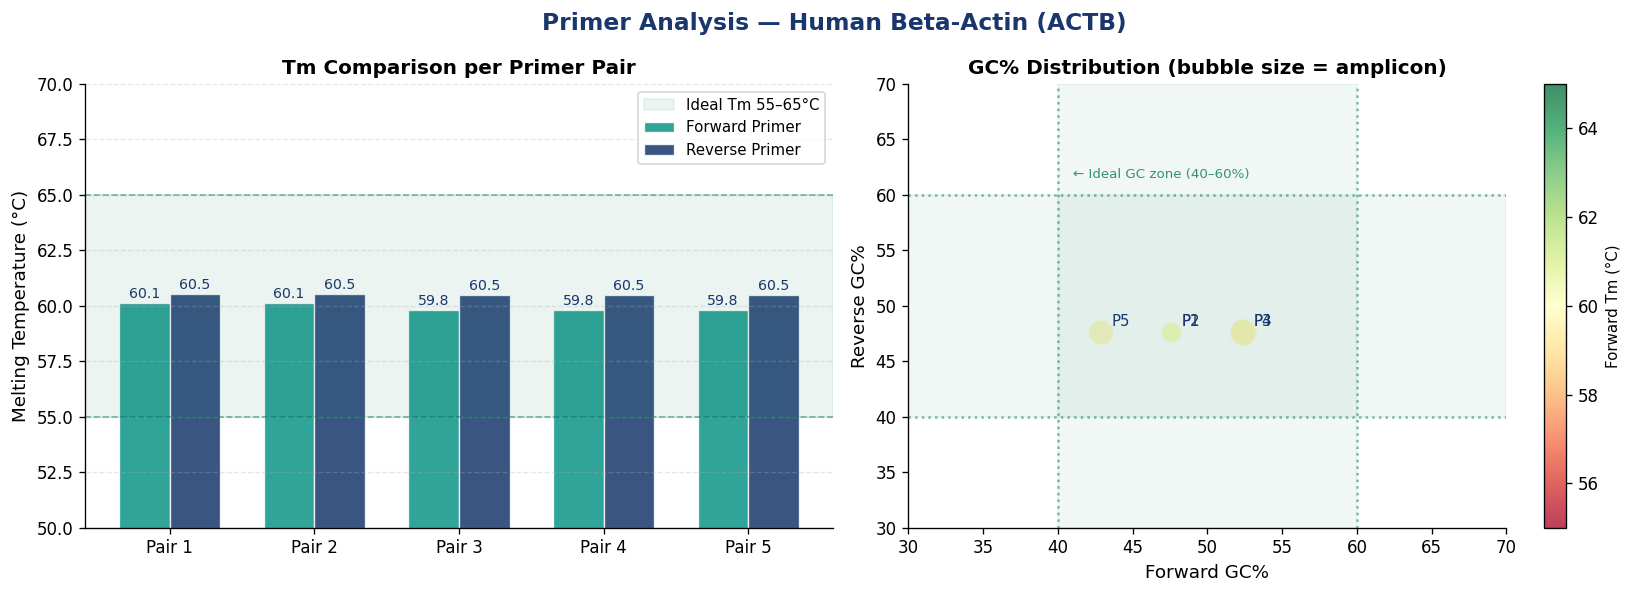

💾 Chart saved as primer_tm_analysis.png

🏆 Recommended Pair: Pair 1 (lowest penalty score: 0.674)
   Forward: 5'-TCACCAACAAAGAGGGCTATG-3'
   Reverse: 5'-AGCTTCTCCTTAATGTCACGC-3'
   Amplicon: 160 bp


In [ ]:
# ============================================================
# CELL 4: Build DataFrame + Tm Visualization
# ============================================================

def results_to_dataframe(results):
    """Convert primer3 results dictionary to a clean pandas DataFrame."""
    n = results.get('PRIMER_PAIR_NUM_RETURNED', 0)
    if n == 0:
        return pd.DataFrame()

    rows = []
    for i in range(n):
        fwd_seq = results.get(f'PRIMER_LEFT_{i}_SEQUENCE', '')
        rev_seq = results.get(f'PRIMER_RIGHT_{i}_SEQUENCE', '')
        rows.append({
            'Pair'           : i + 1,
            'Forward (5-3)' : fwd_seq,
            'Reverse (5-3)' : rev_seq,
            'Fwd_Length'     : len(fwd_seq),
            'Rev_Length'     : len(rev_seq),
            'Tm_Fwd (°C)'   : round(results.get(f'PRIMER_LEFT_{i}_TM', 0), 2),
            'Tm_Rev (°C)'   : round(results.get(f'PRIMER_RIGHT_{i}_TM', 0), 2),
            'GC_Fwd (%)'    : round(results.get(f'PRIMER_LEFT_{i}_GC_PERCENT', 0), 1),
            'GC_Rev (%)'    : round(results.get(f'PRIMER_RIGHT_{i}_GC_PERCENT', 0), 1),
            'Amplicon (bp)' : results.get(f'PRIMER_PAIR_{i}_PRODUCT_SIZE', 0),
            'Penalty'        : round(results.get(f'PRIMER_PAIR_{i}_PENALTY', 0), 3),
        })
    return pd.DataFrame(rows)


def plot_tm_comparison(df):
    """Plot Tm comparison bar chart for all primer pairs."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Primer Analysis — {gene_name}', fontsize=14, fontweight='bold', color=BIOCOGNIZ_BLUE)

    # ── Left: Tm bar chart ──
    ax1 = axes[0]
    x = np.arange(len(df))
    w = 0.35
    bars1 = ax1.bar(x - w/2, df['Tm_Fwd (°C)'], w, label='Forward Primer',
                    color=BIOCOGNIZ_TEAL, alpha=0.85, edgecolor='white', linewidth=0.8)
    bars2 = ax1.bar(x + w/2, df['Tm_Rev (°C)'], w, label='Reverse Primer',
                    color=BIOCOGNIZ_BLUE, alpha=0.85, edgecolor='white', linewidth=0.8)

    # Ideal Tm range shading
    ax1.axhspan(55, 65, alpha=0.08, color=BIOCOGNIZ_GREEN, label='Ideal Tm 55–65°C')
    ax1.axhline(y=55, color=BIOCOGNIZ_GREEN, linestyle='--', alpha=0.5, linewidth=1)
    ax1.axhline(y=65, color=BIOCOGNIZ_GREEN, linestyle='--', alpha=0.5, linewidth=1)

    # Labels on bars
    for bar in bars1:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8.5, color=BIOCOGNIZ_BLUE)
    for bar in bars2:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8.5, color=BIOCOGNIZ_BLUE)

    ax1.set_xticks(x)
    ax1.set_xticklabels([f'Pair {i+1}' for i in range(len(df))], fontsize=10)
    ax1.set_ylabel('Melting Temperature (°C)', fontsize=11)
    ax1.set_title('Tm Comparison per Primer Pair', fontsize=12, fontweight='bold')
    ax1.set_ylim(50, 70)
    ax1.legend(fontsize=9)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.grid(axis='y', alpha=0.3, linestyle='--')

    # ── Right: GC% + Amplicon scatter ──
    ax2 = axes[1]
    scatter = ax2.scatter(
        df['GC_Fwd (%)'], df['GC_Rev (%)'],
        s=df['Amplicon (bp)'], alpha=0.75,
        c=df['Tm_Fwd (°C)'], cmap='RdYlGn',
        vmin=55, vmax=65, edgecolors='white', linewidth=1.5
    )
    cbar = plt.colorbar(scatter, ax=ax2)
    cbar.set_label('Forward Tm (°C)', fontsize=9)

    # Ideal GC zone
    ax2.axvspan(40, 60, alpha=0.06, color=BIOCOGNIZ_GREEN)
    ax2.axhspan(40, 60, alpha=0.06, color=BIOCOGNIZ_GREEN)
    ax2.axvline(x=40, color=BIOCOGNIZ_GREEN, linestyle=':', alpha=0.5)
    ax2.axvline(x=60, color=BIOCOGNIZ_GREEN, linestyle=':', alpha=0.5)
    ax2.axhline(y=40, color=BIOCOGNIZ_GREEN, linestyle=':', alpha=0.5)
    ax2.axhline(y=60, color=BIOCOGNIZ_GREEN, linestyle=':', alpha=0.5)

    # Pair labels
    for _, row in df.iterrows():
        ax2.annotate(f"P{int(row['Pair'])}",
                    (row['GC_Fwd (%)'], row['GC_Rev (%)']),
                    textcoords='offset points', xytext=(6, 4), fontsize=9, color=BIOCOGNIZ_BLUE)

    ax2.set_xlabel('Forward GC%', fontsize=11)
    ax2.set_ylabel('Reverse GC%', fontsize=11)
    ax2.set_title('GC% Distribution (bubble size = amplicon)', fontsize=12, fontweight='bold')
    ax2.set_xlim(30, 70)
    ax2.set_ylim(30, 70)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.text(41, 61.5, '← Ideal GC zone (40–60%)', fontsize=8, color=BIOCOGNIZ_GREEN, alpha=0.8)

    plt.tight_layout()
    plt.savefig('primer_tm_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('💾 Chart saved as primer_tm_analysis.png')


# Build and display table
df = results_to_dataframe(results)

if not df.empty:
    print('📋 Top Primer Pairs — Full Results:')
    print('=' * 80)
    display(df[['Pair','Forward (5-3)', 'Reverse (5-3)', 'Tm_Fwd (°C)',
               'Tm_Rev (°C)', 'GC_Fwd (%)', 'GC_Rev (%)', 'Amplicon (bp)', 'Penalty']].to_string(index=False))
    print()

    # Plot
    plot_tm_comparison(df)

    # Best pair recommendation
    best = df.iloc[0]
    print(f'\n🏆 Recommended Pair: Pair {int(best["Pair"])} (lowest penalty score: {best["Penalty"]})')
    print(f'   Forward: 5\'-{best["Forward (5-3)"]}-3\'')
    print(f'   Reverse: 5\'-{best["Reverse (5-3)"]}-3\'')
    print(f'   Amplicon: {best["Amplicon (bp)"]} bp')
else:
    print('⚠️  No results to display. Rerun Cell 3.')

---
## 🔍 Cell 5: Self-Dimer & Hairpin Analysis

Using thermodynamic calculations (SantaLucia & Hicks, 2004):

| Structure | Threshold | Concern if... |
|-----------|-----------|---------------|
| Self-Dimer | ΔG > -9 kcal/mol | < -9 → primer forms dimers |
| Hairpin | ΔG > -2 kcal/mol | < -2 → intra-molecular folding |

**Reference:** SantaLucia & Hicks (2004) Annu Rev Biophys. DOI: 10.1146/annurev.biophys.32.110601.141800

🔎 Checking self-dimers & hairpins for all primer pairs...
   Conditions: 50 mM NaCl, 1.5 mM MgCl₂, 37°C, 250 nM primer

Pair   Forward Seq              SD_ΔG        HP_ΔG        SD     HP     Status
--------------------------------------------------------------------------------
1      TCACCAACAAAGAGGGCTATG    -2.47        0.00         ✅      ✅      ✅ PASS
2      CATCACCAACAAAGAGGGCTA    -2.47        0.00         ✅      ✅      ✅ PASS
3      CTCATGAAGATCCTCACCGAG    -3.16        0.00         ✅      ✅      ✅ PASS
4      CTCATGAAGATCCTCACCGAG    -3.16        0.00         ✅      ✅      ✅ PASS
5      TGTGCGTGACATTAAGGAGAA    -3.42        0.00         ✅      ✅      ✅ PASS

Thresholds: Self-Dimer ΔG > -9 kcal/mol | Hairpin ΔG > -2 kcal/mol
Reference: SantaLucia & Hicks (2004) Annu Rev Biophys 33:415-440



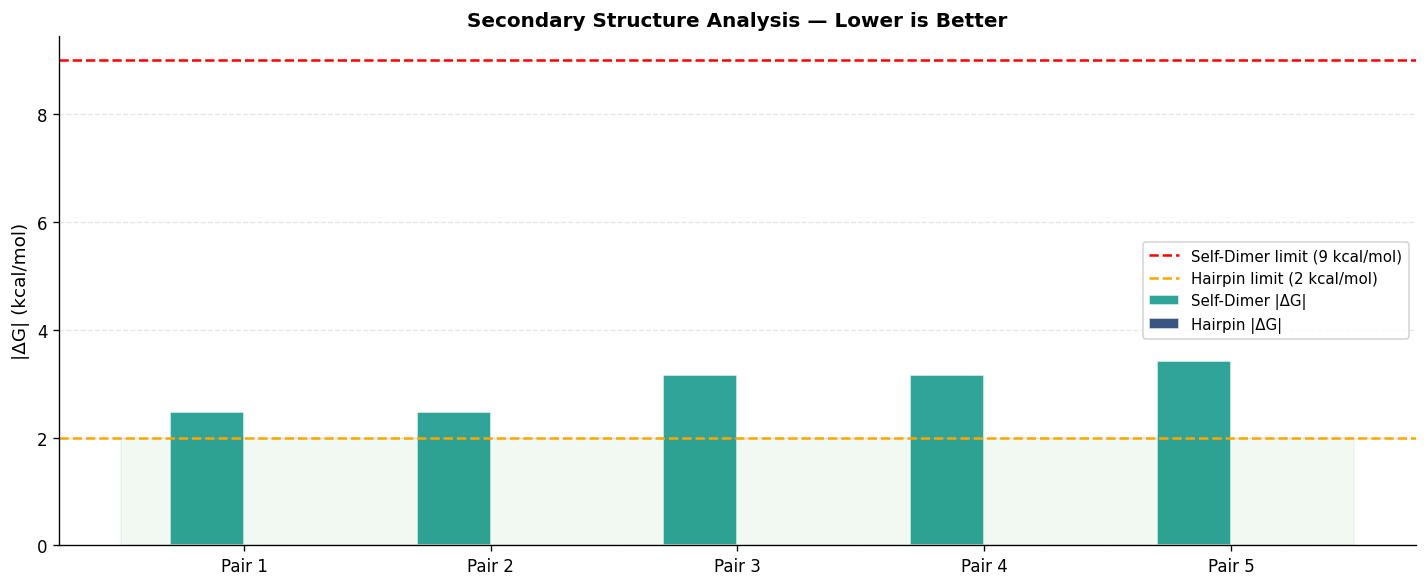

💾 Chart saved as primer_structure_analysis.png


In [ ]:
# ============================================================
# CELL 5: Self-Dimer & Hairpin Analysis
# ============================================================

def check_structures(sequence, label='Primer', mv_conc=50, dv_conc=1.5,
                     dntp_conc=0.2, dna_conc=250, temp_c=37):
    """
    Check self-dimer and hairpin ΔG for a primer sequence.

    Args:
        sequence: primer sequence (uppercase string)
        mv_conc : monovalent salt concentration (mM) — default 50 mM NaCl
        dv_conc : divalent salt concentration (mM) — default 1.5 mM MgCl2
        dntp_conc: dNTP concentration (mM)
        dna_conc: primer concentration (nM)
        temp_c  : temperature for calculation (°C)

    Returns:
        dict: {self_dimer_dg, hairpin_dg, sd_pass, hp_pass, overall_pass}
    """
    try:
        sd = primer3.calcHomodimer(
            sequence, mv_conc=mv_conc, dv_conc=dv_conc,
            dntp_conc=dntp_conc, dna_conc=dna_conc, temp_c=temp_c
        )
        hp = primer3.calcHairpin(
            sequence, mv_conc=mv_conc, dv_conc=dv_conc,
            dntp_conc=dntp_conc, dna_conc=dna_conc, temp_c=temp_c
        )
        sd_dg = round(sd.dg / 1000, 2)   # Convert cal/mol → kcal/mol
        hp_dg = round(hp.dg / 1000, 2)
        sd_pass = sd_dg > -9.0
        hp_pass = hp_dg > -2.0
        return {
            'SelfDimer_dG': sd_dg,
            'Hairpin_dG'  : hp_dg,
            'SD_Pass'     : sd_pass,
            'HP_Pass'     : hp_pass,
            'Overall'     : sd_pass and hp_pass
        }
    except Exception as e:
        return {'SelfDimer_dG': 0, 'Hairpin_dG': 0, 'SD_Pass': True, 'HP_Pass': True, 'Overall': True}


def plot_dimer_analysis(qc_rows):
    """Bar chart of self-dimer and hairpin ΔG for all pairs."""
    fig, ax = plt.subplots(figsize=(12, 5))

    pairs = [r['Pair'] for r in qc_rows]
    sd_vals = [abs(r['SD_Fwd_dG']) for r in qc_rows]
    hp_vals = [abs(r['HP_Fwd_dG']) for r in qc_rows]
    x = np.arange(len(pairs))
    w = 0.3

    ax.bar(x - w/2, sd_vals, w, label='Self-Dimer |ΔG|', color=BIOCOGNIZ_TEAL, alpha=0.85, edgecolor='white')
    ax.bar(x + w/2, hp_vals, w, label='Hairpin |ΔG|', color=BIOCOGNIZ_BLUE, alpha=0.85, edgecolor='white')

    ax.axhline(y=9, color='red', linestyle='--', linewidth=1.5, label='Self-Dimer limit (9 kcal/mol)')
    ax.axhline(y=2, color='orange', linestyle='--', linewidth=1.5, label='Hairpin limit (2 kcal/mol)')

    ax.set_xticks(x)
    ax.set_xticklabels([f'Pair {p}' for p in pairs], fontsize=10)
    ax.set_ylabel('|ΔG| (kcal/mol)', fontsize=11)
    ax.set_title('Secondary Structure Analysis — Lower is Better', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.fill_between([-0.5, len(pairs)-0.5], 0, 2, alpha=0.05, color='green', label='Safe zone (hairpin)')

    plt.tight_layout()
    plt.savefig('primer_structure_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('💾 Chart saved as primer_structure_analysis.png')


# Run QC checks
n = results.get('PRIMER_PAIR_NUM_RETURNED', 0)
print('🔎 Checking self-dimers & hairpins for all primer pairs...')
print('   Conditions: 50 mM NaCl, 1.5 mM MgCl₂, 37°C, 250 nM primer')
print()
print(f'{"Pair":<6} {"Forward Seq":<24} {"SD_ΔG":<12} {"HP_ΔG":<12} {"SD":<6} {"HP":<6} {"Status"}')
print('-' * 80)

qc_rows = []
for i in range(n):
    fwd = results.get(f'PRIMER_LEFT_{i}_SEQUENCE', '')
    rev = results.get(f'PRIMER_RIGHT_{i}_SEQUENCE', '')
    qc_f = check_structures(fwd)
    qc_r = check_structures(rev)

    sd_icon = '✅' if qc_f['SD_Pass'] else '⚠️'
    hp_icon = '✅' if qc_f['HP_Pass'] else '⚠️'
    overall = '✅ PASS' if qc_f['Overall'] and qc_r['Overall'] else '⚠️ REVIEW'

    print(f'{i+1:<6} {fwd[:22]:<24} {qc_f["SelfDimer_dG"]:<12.2f} {qc_f["Hairpin_dG"]:<12.2f} '
          f'{sd_icon:<6} {hp_icon:<6} {overall}')

    qc_rows.append({
        'Pair': i+1, 'Fwd': fwd, 'Rev': rev,
        'SD_Fwd_dG': qc_f['SelfDimer_dG'], 'HP_Fwd_dG': qc_f['Hairpin_dG'],
        'SD_Rev_dG': qc_r['SelfDimer_dG'], 'HP_Rev_dG': qc_r['Hairpin_dG'],
        'SD_Pass': qc_f['SD_Pass'] and qc_r['SD_Pass'],
        'HP_Pass': qc_f['HP_Pass'] and qc_r['HP_Pass'],
        'QC_Result': overall
    })

print()
print('Thresholds: Self-Dimer ΔG > -9 kcal/mol | Hairpin ΔG > -2 kcal/mol')
print('Reference: SantaLucia & Hicks (2004) Annu Rev Biophys 33:415-440')
print()

# Plot
plot_dimer_analysis(qc_rows)

---
## 🖱️ Cell 6: Interactive Widget — Try Your Own Sequence!

Paste **any DNA sequence** (FASTA or raw) into the box below and click **Design Primers** to run the full pipeline.  
The widget calls all functions from previous cells automatically.

> **🎓 Student Exercise:** Paste the GAPDH sequence from the slide to complete your practice task!

In [ ]:
# ============================================================
# CELL 6: Interactive Widget
# ============================================================

def parse_fasta_or_raw(text):
    """Accept FASTA format or raw sequence, return clean uppercase DNA string."""
    lines = text.strip().splitlines()
    if lines and lines[0].startswith('>'):
        seq = ''.join(l.strip() for l in lines[1:] if l.strip())
    else:
        seq = ''.join(lines).strip()
    # Keep only valid DNA characters
    seq = ''.join(c for c in seq.upper() if c in 'ACGTN')
    return seq


def run_full_pipeline(seq_text, opt_tm, min_tm, max_tm, min_gc, max_gc, n_pairs, prod_min, prod_max):
    """Complete primer design pipeline: parse → design → QC → display."""
    seq = parse_fasta_or_raw(seq_text)

    if len(seq) < 80:
        print('❌ Sequence too short (min 80 bp). Please provide a longer sequence.')
        return None

    gc = (seq.count('G') + seq.count('C')) / len(seq) * 100
    print(f'✅ Parsed sequence: {len(seq)} bp | GC: {gc:.1f}%')
    print(f'🔬 Running Primer3 (Tm: {min_tm}–{max_tm}°C | GC: {min_gc}–{max_gc}% | Product: {prod_min}–{prod_max} bp)...')

    res = design_primers(
        seq, gene_id='CUSTOM',
        opt_tm=opt_tm, min_tm=min_tm, max_tm=max_tm,
        min_gc=min_gc, max_gc=max_gc, n_pairs=n_pairs,
        product_min=prod_min, product_max=prod_max
    )

    if not res or res.get('PRIMER_PAIR_NUM_RETURNED', 0) == 0:
        print('⚠️  No primer pairs found. Try adjusting the parameters.')
        return None

    df_custom = results_to_dataframe(res)
    print(f'\n✅ Found {len(df_custom)} primer pair(s)!')
    display(df_custom[['Pair','Forward (5-3)','Reverse (5-3)','Tm_Fwd (°C)','Tm_Rev (°C)',
                        'GC_Fwd (%)','GC_Rev (%)','Amplicon (bp)','Penalty']])

    plot_tm_comparison(df_custom)
    return df_custom, res


# ── Widget Layout ──
display(HTML('<h3 style="color:#19376D">🧬 Biocogniz Interactive Primer Designer</h3>'))
display(HTML('<p style="color:#64748B">Paste your sequence below (FASTA or raw DNA). Adjust parameters if needed, then click Design Primers.</p>'))

seq_box = widgets.Textarea(
    value=gene_sequence,
    placeholder='Paste DNA sequence here (FASTA or raw)...',
    description='Sequence:',
    layout=widgets.Layout(width='90%', height='100px')
)

opt_tm_slider  = widgets.FloatSlider(value=60, min=50, max=70, step=0.5, description='Opt Tm (°C):', style={'description_width': 'initial'})
min_tm_slider  = widgets.FloatSlider(value=57, min=45, max=68, step=0.5, description='Min Tm (°C):', style={'description_width': 'initial'})
max_tm_slider  = widgets.FloatSlider(value=63, min=52, max=72, step=0.5, description='Max Tm (°C):', style={'description_width': 'initial'})
min_gc_slider  = widgets.FloatSlider(value=40, min=20, max=80, step=5, description='Min GC% :', style={'description_width': 'initial'})
max_gc_slider  = widgets.FloatSlider(value=60, min=30, max=90, step=5, description='Max GC% :', style={'description_width': 'initial'})
n_pairs_slider = widgets.IntSlider(value=5, min=1, max=10, description='# Pairs :', style={'description_width': 'initial'})
prod_min_box   = widgets.IntText(value=100, description='Amplicon min (bp):', style={'description_width': 'initial'})
prod_max_box   = widgets.IntText(value=300, description='Amplicon max (bp):', style={'description_width': 'initial'})

btn = widgets.Button(
    description='🔬 Design Primers',
    button_style='success',
    layout=widgets.Layout(width='200px', height='40px')
)
out = widgets.Output()

def on_click(_):
    with out:
        clear_output(wait=True)
        print('=' * 60)
        run_full_pipeline(
            seq_box.value,
            opt_tm_slider.value, min_tm_slider.value, max_tm_slider.value,
            min_gc_slider.value, max_gc_slider.value,
            n_pairs_slider.value, prod_min_box.value, prod_max_box.value
        )
        print('=' * 60)

btn.on_click(on_click)

params_box = widgets.HBox([
    widgets.VBox([opt_tm_slider, min_tm_slider, max_tm_slider]),
    widgets.VBox([min_gc_slider, max_gc_slider, n_pairs_slider]),
    widgets.VBox([prod_min_box, prod_max_box])
])

display(widgets.VBox([seq_box, params_box, btn, out]))

---
## 📁 Cell 7: Export Results to CSV

Export the complete results table including QC scores to a CSV file.  
In Google Colab, this also triggers an automatic download.

In [ ]:
# ============================================================
# CELL 7: Export to CSV
# ============================================================

def build_full_report(results_dict, gene_name_str, qc_rows_list):
    """Combine primer pairs with QC scores into final export DataFrame."""
    df_main = results_to_dataframe(results_dict)
    if df_main.empty:
        return pd.DataFrame()

    qc_df = pd.DataFrame(qc_rows_list)[['Pair','SD_Fwd_dG','HP_Fwd_dG','SD_Rev_dG','HP_Rev_dG','QC_Result']]
    merged = df_main.merge(qc_df, on='Pair', how='left')
    merged.insert(0, 'Gene', gene_name_str)
    merged.insert(0, 'Workshop', 'Biocogniz — Primer Design Workshop')
    merged.insert(0, 'Instructor', 'Aarsha (Aarsha@biocogniz.com)')
    return merged


# Build full report
full_df = build_full_report(results, gene_name, qc_rows)

if not full_df.empty:
    filename = f'biocogniz_primer_results_{gene_id}.csv'
    full_df.to_csv(filename, index=False)
    print(f'✅ Results saved to: {filename}')
    print(f'   Rows: {len(full_df)} | Columns: {len(full_df.columns)}')
    print()
    display(HTML(full_df.to_html(index=False, border=1)))

    # Colab download
    try:
        from google.colab import files
        files.download(filename)
        print('⬇️  Auto-download triggered — check your Downloads folder!')
    except ImportError:
        print(f'ℹ️  Not in Colab — file saved locally as: {filename}')
else:
    print('⚠️  No results to export. Run Cells 3–5 first.')

✅ Results saved to: biocogniz_primer_results_ACTB.csv
   Rows: 5 | Columns: 19



Instructor,Workshop,Gene,Pair,Forward (5-3),Reverse (5-3),Fwd_Length,Rev_Length,Tm_Fwd (°C),Tm_Rev (°C),GC_Fwd (%),GC_Rev (%),Amplicon (bp),Penalty,SD_Fwd_dG,HP_Fwd_dG,SD_Rev_dG,HP_Rev_dG,QC_Result
Aarsha (Aarsha@biocogniz.com),Biocogniz — Primer Design Workshop,Human Beta-Actin (ACTB),1,TCACCAACAAAGAGGGCTATG,AGCTTCTCCTTAATGTCACGC,21,21,60.13,60.54,47.6,47.6,160,0.674,-2.47,0.0,-2.14,0.0,✅ PASS
Aarsha (Aarsha@biocogniz.com),Biocogniz — Primer Design Workshop,Human Beta-Actin (ACTB),2,CATCACCAACAAAGAGGGCTA,AGCTTCTCCTTAATGTCACGC,21,21,60.13,60.54,47.6,47.6,162,0.674,-2.47,0.0,-2.14,0.0,✅ PASS
Aarsha (Aarsha@biocogniz.com),Biocogniz — Primer Design Workshop,Human Beta-Actin (ACTB),3,CTCATGAAGATCCTCACCGAG,GTCCACGTCACACTTCATGAT,21,21,59.79,60.47,52.4,47.6,300,0.680,-3.16,0.0,-4.14,0.0,✅ PASS
Aarsha (Aarsha@biocogniz.com),Biocogniz — Primer Design Workshop,Human Beta-Actin (ACTB),4,CTCATGAAGATCCTCACCGAG,TGAAGGTAGTTTCGTGGATGC,21,21,59.79,60.47,52.4,47.6,274,0.681,-3.16,0.0,-1.92,0.0,✅ PASS
Aarsha (Aarsha@biocogniz.com),Biocogniz — Primer Design Workshop,Human Beta-Actin (ACTB),5,TGTGCGTGACATTAAGGAGAA,GTCCACGTCACACTTCATGAT,21,21,59.79,60.47,42.9,47.6,241,0.685,-3.42,0.0,-4.14,0.0,✅ PASS


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Auto-download triggered — check your Downloads folder!


---
## 🎓 Student Practice Task: GAPDH

**Instructions (20 minutes):**

1. Copy the GAPDH sequence below
2. Paste it into the **interactive widget** in Cell 6
3. Click **Design Primers**
4. Note: Forward sequence, Reverse sequence, Tm, GC%, Amplicon size
5. Check QC scores (do your primers pass?)
6. Run Cell 7 to export your results CSV
7. **BONUS:** Change Tm range to 58–62°C and observe how results change

```
>GAPDH_CDS_partial NM_002046.7
ATGGGGAAGGTGAAGGTCGGAGTCAACGGATTTGGTCGTATTGGGCGCCTGGTCACCAGGGCTGCTTTTAAC
TCTGCACTGTGAATGACATCAAGAAGGTGGTGAAGCAGGCATCTGAGGGCCCACTGAAGGGTGGAGCCAAAG
GGGAGCCGCACCAGAGTCCTTCCACGATACCAAAGTTGTCATGGATGACCTTGGCCAGGTGGTCAAACACGGT
TGCCATGGAGGGCATCCTGGGCTACACTGAGCACCAGGTGGTTTCTTTTGCAGCAGGTCAGCCCCATCTTCCT
```

**Expected Output (reference answers on workshop slide 25):**
- Forward: 5'-ATGGGGAAGGTGAAGGTCGG-3' | Tm ≈ 60.4°C | GC = 55%
- Amplicon: ~142 bp | Self-Dimer ΔG > -9 kcal/mol ✅

---
## 📚 Workshop Summary & Resources

### What We Covered:
| Step | Tool/Method | Output |
|------|-------------|--------|
| Sequence Input | NCBI RefSeq / FASTA | Gene sequence |
| Primer Design | primer3-py | Top 5 primer pairs |
| QC Analysis | primer3.calcHomodimer/Hairpin | ΔG scores |
| Visualization | matplotlib | Tm chart, GC scatter |
| Export | pandas → CSV | Downloadable results |

### 🔗 Key Resources:
- **Primer3 Web:** https://primer3.ut.ee
- **NCBI Primer-BLAST:** https://www.ncbi.nlm.nih.gov/tools/primer-blast
- **IDT OligoAnalyzer:** https://eu.idtdna.com/calc/analyzer
- **primer3-py docs:** https://primer3-py.readthedocs.io
- **MIQE Guidelines:** DOI 10.1373/clinchem.2008.112797

### 📧 Contact Aarsha:
**aarshabiocogniz@gmail.com** |info@biocogniz.com Biocogniz

---
*This notebook was created for the Biocogniz Workshop on Primer Design & In Silico Analysis.*  
*All code is open for educational use. Please cite Primer3 (Untergasser et al. 2012) in any publications.*